In [1]:
import pandas, urllib, numpy

In [2]:
import statsmodels, statsmodels.stats, statsmodels.stats.multitest

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [4]:
# pip install git+https://github.com/Maayanlab/maayanlab-bioinformatics.git
import maayanlab_bioinformatics, maayanlab_bioinformatics.enrichment

# define library

In [5]:
enrichr_library = 'ChEA_2022'
#enrichr_library = 'ARCHS4_TFs_Coexp'

input_file = '029 orsay Table DEGs - HOM.tsv'
input_file = '029 orsay Table DEGs - VGA.tsv'
input_file = '029 orsay Table DEGs - particular to HOM.tsv'
#input_file = '029 orsay Table DEGs - particular to VGA.tsv'
#input_file = '029 orsay Table DEGs - both HOM & VGA.tsv'

outputfile = 'tf_enricher.' + enrichr_library + input_file + '.tsv'

# read data

In [6]:
df = pandas.read_csv(input_file, sep='\t')
original = df['Gene name'].values
gene_list_input = [element.upper() for element in original]
print(len(gene_list_input), gene_list_input[:10])

151 ['F630028O10RIK', 'CD163', 'IQGAP2', 'MRAP', 'D130058E05RIK', 'MID1', 'MCOLN2', 'ADCY1', 'KRT19', 'SPINT1']


In [7]:
def get_library(lib_name):
    '''
    Returns a dictionary mapping each term from the input library to 
    its associated geneset. 
    '''
    raw_lib_data = []

    with urllib.request.urlopen('https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName=' + lib_name) as f:
        for line in f.readlines():
            raw_lib_data.append(line.decode("utf-8").split("\t\t"))

    name = []
    gene_list = []
    lib_data = {}

    for i in range(len(raw_lib_data)):
        name += [raw_lib_data[i][0]]
        raw_genes = raw_lib_data[i][1].replace('\t', ' ')
        gene_list += [raw_genes[:-1]]
    
    lib_data = {a[0]:a[1].split(' ') for a in zip(name, gene_list)}
    return lib_data

lib_data = get_library(enrichr_library)

enrich_results = maayanlab_bioinformatics.enrichment.enrich_crisp(gene_list_input, lib_data, 21000, True)

res_df = pandas.DataFrame(
    [ [
        term, 
        res.pvalue, 
        res.odds_ratio,
        res.n_overlap,

    ] for (term, res) in enrich_results ], 
    columns=['term', 'pvalue', 'odds_ratio', 'n_overlap']
)
res_df

,term,pvalue,odds_ratio,n_overlap
0,TP63 17297297 ChIP-ChIP HaCaT Human,0.223362,4.081373,1
1,STAT6 21828071 ChIP-Seq BEAS2B Human,0.217728,4.205253,1
2,CIITA 18437201 ChIP-ChIP Raji B And iDC Human,0.267007,3.302698,1
3,GATA2 26923725 Chip-Seq HEMANGIOBLAST Mouse,0.397089,2.007729,1
4,TRIM28 21343339 ChIP-Seq HEK293 Human,0.422725,1.846578,1
...,...,...,...,...
685,GATA3 30127528 ChIP-Seq BE2C Human Brain Neuro...,0.056560,1.841953,10
686,MYC 30127528 ChIP-Seq KELLY Human Brain Neurob...,1.000000,0.252748,9
687,IRF1 21803131 ChIP-Seq PrimaryMonocytes Human ...,0.439210,1.752743,1
688,NR3C2 34362910 ChIP-Seq WistarRat Hippocampus,0.995389,0.352776,4


In [8]:
# add gene names
container = []
for pathway in res_df['term']:
    
    overlap_genes = []
    for query in lib_data[pathway]:
        if query in gene_list_input:
            overlap_genes.append(query)
    mouse_overlap_genes = [element.lower().title() for element in overlap_genes]
    overlap_genes_string = ', '.join(mouse_overlap_genes)
    container.append(overlap_genes_string)

res_df.loc[:, 'overlap_genes'] = container
res_df

,term,pvalue,odds_ratio,n_overlap,overlap_genes
0,TP63 17297297 ChIP-ChIP HaCaT Human,0.223362,4.081373,1,Serpinb5
1,STAT6 21828071 ChIP-Seq BEAS2B Human,0.217728,4.205253,1,Rab27B
2,CIITA 18437201 ChIP-ChIP Raji B And iDC Human,0.267007,3.302698,1,Parvg
3,GATA2 26923725 Chip-Seq HEMANGIOBLAST Mouse,0.397089,2.007729,1,Msr1
4,TRIM28 21343339 ChIP-Seq HEK293 Human,0.422725,1.846578,1,Krt19
...,...,...,...,...,...
685,GATA3 30127528 ChIP-Seq BE2C Human Brain Neuro...,0.056560,1.841953,10,"Syt15, Pcbd1, Mapk13, Mid1, Cdk15, Cd200R1, Pi..."
686,MYC 30127528 ChIP-Seq KELLY Human Brain Neurob...,1.000000,0.252748,9,"Lars2, Adcy1, Nrxn1, Elovl4, Scrn1, Colec11, I..."
687,IRF1 21803131 ChIP-Seq PrimaryMonocytes Human ...,0.439210,1.752743,1,Igsf6
688,NR3C2 34362910 ChIP-Seq WistarRat Hippocampus,0.995389,0.352776,4,"Iqgap2, Ano3, Npr3, Nrxn1"


In [9]:
# multiple test correction
results = statsmodels.stats.multitest.multipletests(res_df['pvalue'], alpha=0.05, method='fdr_bh')
res_df['adjusted'] = results[1]

(690, 6)
(0, 6)


ValueError: zero-size array to reduction operation minimum which has no identity

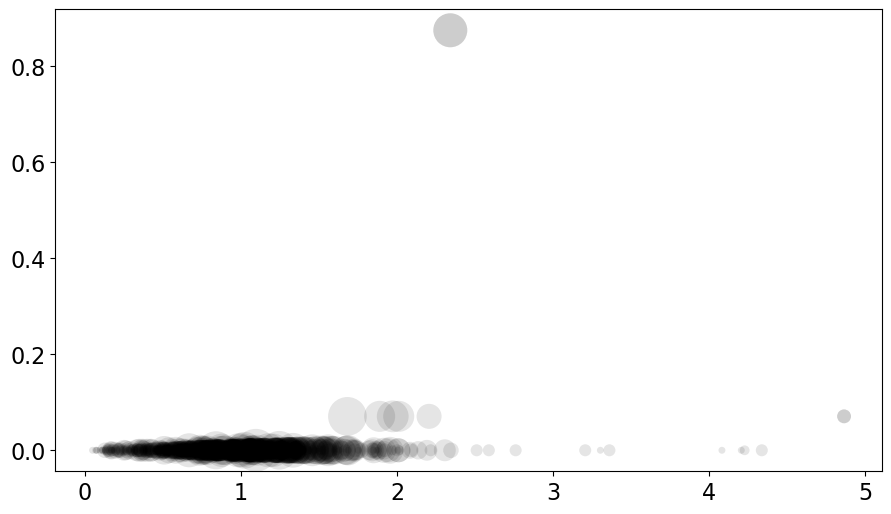

In [10]:
# plot

def importance_calculator(x, y, w):

    xnorm = (x - numpy.min(x)) / (numpy.max(x) - numpy.min(x))
    ynorm = (y - numpy.min(y)) / (numpy.max(y) - numpy.min(y))
    wnorm = (w - numpy.min(w)) / (numpy.max(w) - numpy.min(w))
    
    importance = [numpy.sqrt(xnorm[i]**2 + ynorm[i]**2 + wnorm[i]**2) for i in range(len(x))]
    return importance

inflation = 25

a = res_df[(res_df['adjusted'] > 0.05) | (res_df['odds_ratio'] < 2)]
print(a.shape)
x = a['odds_ratio']
y = -numpy.log10(a['adjusted'])
s = a['n_overlap']
matplotlib.pyplot.scatter(x, y, s*inflation, alpha=1/10, edgecolors='none', color='black')

b = res_df[(res_df['adjusted'] < 0.05) & (res_df['odds_ratio'] > 2)]
print(b.shape)
x = b['odds_ratio']
y = -numpy.log10(b['adjusted'])
s = b['n_overlap']
sc = matplotlib.pyplot.scatter(x, y, s*inflation, alpha=1/2, edgecolors='none', color='skyblue')

x = list(b['odds_ratio'])
y = list(-numpy.log10(b['adjusted']))
prez = list(b['term'].values)
z = [element.split()[-1] for element in prez]
importance = importance_calculator(x, y, s.values)
b.loc[:, 'importance'] = importance
c = b.sort_values('importance', ascending=False)

In [ ]:
# store list 
print(c.shape)
c.drop('pvalue', axis='columns', inplace=True)
d = c.iloc[:, [0, 5, 4, 1, 2, 3]]
d.rename(columns={"term": "Term", 
                  "importance": "Priority", 
                  'adjusted':'Adjusted P', 
                  'odds_ratio':'Odds ratio',
                 'n_overlap':'N overlap',
                 'overlap_genes':'Overlap genes'}, inplace=True)
d.set_index('Term', inplace=True)
d.head()
d.to_csv(outputfile, sep='\t')

d